# 05 — Финальный отчет: стратегии, капитал, устойчивость

Итог всех этапов исследования (01 — инфраструктура, 02 — вселенная стратегий,
03 — управление позицией, 04 — закономерности и фильтры) плюс финальный слой:

* **управление капиталом** — Kelly (classical / fractional / half / quarter),
  рассчитанный из мат. ожидания, дисперсии, вероятности выигрыша и отношения
  средней прибыли к среднему убытку; ограничение максимальной доли капитала
  и лимит риска портфеля;
* **Monte Carlo** последовательностей сделок: вероятность разорения,
  распределения итоговой доходности и просадок, устойчивость Kelly;
* **Walk-Forward валидация** с пере-оптимизацией параметров в каждом окне;
* сводная **оценка риска переобучения** и рекомендации.

> Прогон на синтетическом инструменте `SAMPLE` (Yahoo Finance недоступен из
> этой среды): все числа демонстрируют работу методологии, а не рыночные
> рекомендации. С реальными данными ноутбук выполняется без изменений.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.backtesting import BacktestConfig, ExitRules, managed_portfolio
from src.data import load_data
from src.optimization import (
    WalkForwardConfig,
    exit_research,
    mechanic_scoreboard,
    research_universe,
    summarize_mechanics,
    summarize_strategies,
    top_configurations,
    walk_forward,
    walk_forward_summary,
)
from src.risk import (
    TradeStats,
    kelly_estimate_stability,
    kelly_robustness,
    simulate_trade_sequences,
    sizing_menu,
)
from src.strategies import available_strategies, get_strategy
from src.utils.paths import RESULTS_DIR
from src.visualization import setup_github_rendering, show

setup_github_rendering()
pd.set_option("display.width", 220)

out_dir = RESULTS_DIR / "final_report"
out_dir.mkdir(parents=True, exist_ok=True)

## 1. Данные

In [2]:
SYMBOL = "AAPL"
try:
    data = load_data("yahoo", SYMBOL, start="2018-01-01", end="2025-06-30")
    print("Данные получены из Yahoo Finance")
except Exception as exc:
    print(f"Yahoo Finance недоступен ({type(exc).__name__}), используем локальный CSV")
    SYMBOL = "SAMPLE"
    data = load_data("csv", SYMBOL)

ohlcv = data.get(SYMBOL)
print(f"{SYMBOL}: {len(ohlcv)} баров {ohlcv.index[0].date()}..{ohlcv.index[-1].date()}")

2026-07-04 12:34:30,067 | INFO    | src.data.yahoo_loader | Downloading AAPL from Yahoo Finance (1d, 2018-01-01..2025-06-30)


Failed to get ticker 'AAPL' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.



1 Failed download:


['AAPL']: ProxyError('Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Yahoo Finance недоступен (ValueError), используем локальный CSV
SAMPLE: 2000 баров 2018-01-01..2025-08-29


## 2. ТОП стратегий и лучшие параметры (этап 02, полный пересчет)

Полный прогон вселенной из 26 стратегий (~850 конфигураций) с IS/OOS 70/30
и интегральным рейтингом. Репрезентативная конфигурация каждой стратегии —
лучшая по robust score, **не по доходности**.

In [3]:
names = [n for n in available_strategies() if n != "ma_crossover"]
combined = research_universe(names, ohlcv, show_progress=True)
strategy_summary = summarize_strategies(combined)
strategy_summary.to_csv(out_dir / "strategy_ranking.csv")

TOP_TABLE_COLS = ["category", "robust_score", "is_sharpe", "oos_sharpe",
                  "oos_cagr_pct", "oos_max_dd_pct", "overfit_flags"]
print("=== ТОП-10 СТРАТЕГИЙ (по robust score) ===")
strategy_summary[TOP_TABLE_COLS].head(10).round(3)

strategies:   0%|          | 0/26 [00:00<?, ?it/s]

=== ТОП-10 СТРАТЕГИЙ (по robust score) ===


,category,robust_score,is_sharpe,oos_sharpe,oos_cagr_pct,oos_max_dd_pct,overfit_flags
strategy,,,,,,,
ema_rsi,hybrid,0.824,0.702,0.945,11.111,7.895,1
roc_momentum,momentum,0.778,0.836,0.916,12.464,9.426,0
ichimoku,trend,0.704,0.524,0.997,11.324,12.863,0
supertrend,trend,0.609,0.610,0.663,8.362,14.516,0
triple_ema,trend,0.601,0.531,0.581,6.172,10.916,0
macd_trend_filter,hybrid,0.594,0.453,0.504,4.445,9.759,3
vwap_volume,hybrid,0.586,0.641,0.499,3.169,5.004,0
stochastic,mean_reversion,0.564,0.346,0.668,3.521,4.069,1
ema_adx,hybrid,0.560,0.494,1.154,14.803,12.664,0


In [4]:
print("=== Лучшие параметры топ-6 (без ложных чемпионов: overfit_flags < 2) ===")
healthy = strategy_summary[strategy_summary["overfit_flags"] < 2]
TOP_STRATEGIES = healthy.head(6).index.tolist()
best_params = {n: strategy_summary.loc[n, "best_params"] for n in TOP_STRATEGIES}
pd.DataFrame({
    "params": {k: str(v) for k, v in best_params.items()},
    "robust_score": strategy_summary.loc[TOP_STRATEGIES, "robust_score"].round(3),
})

=== Лучшие параметры топ-6 (без ложных чемпионов: overfit_flags < 2) ===


,params,robust_score
ema_rsi,"{'fast_window': 10, 'slow_window': 150, 'pullb...",0.824
roc_momentum,"{'window': 20, 'threshold': 0.0}",0.778
ichimoku,"{'tenkan_window': 12, 'kijun_window': 22, 'sen...",0.704
supertrend,"{'window': 14, 'multiplier': 1.5}",0.609
triple_ema,"{'fast_window': 5, 'slow_window': 150, 'mid_wi...",0.601
vwap_volume,"{'window': 20, 'threshold': 0.02, 'vol_multipl...",0.586


## 3. Лучшие методы управления позицией (этап 03, пересчет)

Каждая механика оптимизируется на IS и судится на OOS против baseline
(выход по противоположному сигналу).

In [5]:
sweep = exit_research(best_params, ohlcv, show_progress=True)
mech = summarize_mechanics(sweep)
board = mechanic_scoreboard(mech)
board.to_csv(out_dir / "mechanic_scoreboard.csv")
board[["real improvement", "false improvement", "no effect / worse",
       "real_rate", "mean_d_oos_sharpe", "mean_d_oos_max_dd"]].round(3)

strategies:   0%|          | 0/6 [00:00<?, ?it/s]

verdict,real improvement,false improvement,no effect / worse,real_rate,mean_d_oos_sharpe,mean_d_oos_max_dd
mechanic,,,,,,
take_profit,4,1,1,0.667,0.207,-1.213
combo_trail_partial,3,3,0,0.500,0.089,-1.470
partial_tp,3,3,0,0.500,0.089,-1.470
trail_replaces_signal,2,4,0,0.333,-0.088,7.108
combo_sl_tp,1,5,0,0.167,0.029,-0.153
time_stop,1,3,1,0.167,-0.149,0.651
combo_sl_tp_time,1,3,1,0.167,-0.178,0.391
combo_sl_trail_be,0,3,2,0.000,0.003,-0.060
stop_loss,0,3,3,0.000,0.000,0.000


In [6]:
real = mech[mech["verdict"] == "real improvement"].sort_values("d_oos_sharpe_ratio", ascending=False)
print("Реально работающие связки (стратегия + механика):")
real[["strategy", "mechanic", "best_label", "d_oos_sharpe_ratio", "d_oos_max_drawdown_pct"]].round(3)

Реально работающие связки (стратегия + механика):


,strategy,mechanic,best_label,d_oos_sharpe_ratio,d_oos_max_drawdown_pct
29,roc_momentum,take_profit,tp=0.05,0.447,-1.603
40,supertrend,take_profit,tp=0.08,0.293,-4.075
45,triple_ema,combo_sl_tp,"sl=0.05,tp=0.2",0.278,0.000
51,triple_ema,take_profit,tp=0.2,0.278,0.000
26,roc_momentum,combo_trail_partial,"trail=0.15,partial=0.05",0.234,-1.603
27,roc_momentum,partial_tp,partial=0.05x0.5,0.234,-1.603
7,ema_rsi,take_profit,tp=0.05,0.224,-1.601
4,ema_rsi,combo_trail_partial,"trail=0.15,partial=0.05",0.223,-1.629
5,ema_rsi,partial_tp,partial=0.05x0.5,0.223,-1.629
53,triple_ema,trail_replaces_signal,trail_only=0.15,0.183,2.941


## 4. Walk-Forward валидация

Окно 1000 баров обучения + 250 баров теста, шаг 250: параметры
**пере-оптимизируются в каждом окне** только на его train-части.
`wf_efficiency` = средний OOS Sharpe / средний IS Sharpe;
`param_stability` — как часто соседние окна выбирают одни и те же параметры.

In [7]:
WF_STRATEGIES = TOP_STRATEGIES[:4]
wf_cfg = WalkForwardConfig(train_bars=1000, test_bars=250, step_bars=250)

wf_windows, wf_rows = {}, []
for name in WF_STRATEGIES:
    windows = walk_forward(name, ohlcv, cfg=wf_cfg, show_progress=False)
    wf_windows[name] = windows
    wf_rows.append(walk_forward_summary(windows).rename(name))
wf_table = pd.DataFrame(wf_rows)
wf_table.to_csv(out_dir / "walk_forward_summary.csv")
wf_table.round(3)

,n_windows,mean_is_sharpe,mean_oos_sharpe,wf_efficiency,pct_profitable_windows,mean_oos_return_pct,worst_oos_drawdown_pct,param_stability
ema_rsi,4.0,1.561,0.850,0.545,0.50,9.056,9.183,0.000
roc_momentum,4.0,1.168,0.433,0.371,0.50,3.997,8.982,0.667
ichimoku,4.0,0.940,0.685,0.728,0.75,4.187,7.141,0.000
supertrend,4.0,1.303,-0.258,-0.198,0.50,-0.913,13.700,0.333


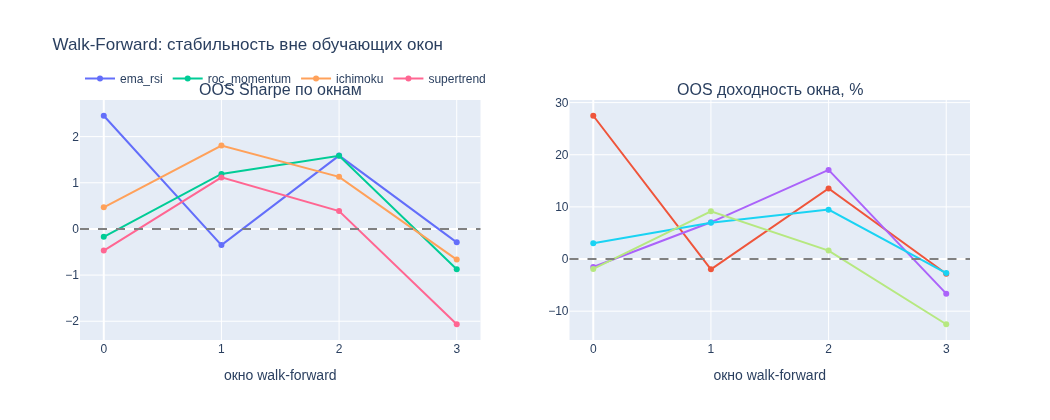

In [8]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("OOS Sharpe по окнам", "OOS доходность окна, %"))
for name in WF_STRATEGIES:
    w = wf_windows[name]
    fig.add_trace(go.Scatter(x=w["window"], y=w["oos_sharpe_ratio"], mode="lines+markers", name=name),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=w["window"], y=w["oos_total_return_pct"], mode="lines+markers",
                             name=name, showlegend=False), row=1, col=2)
for col in (1, 2):
    fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=col)
fig.update_xaxes(title_text="окно walk-forward")
fig.update_layout(width=1050, height=420, title="Walk-Forward: стабильность вне обучающих окон",
                  legend=dict(orientation="h", y=1.15))
show(fig)

## 5. Управление капиталом: Kelly с ограничениями

Берем две лучшие связки этапа 03 и считаем Kelly обоими способами:

* **дискретный**: `f* = p − (1−p)/b` из вероятности выигрыша `p` и отношения
  средней прибыли к среднему убытку `b`;
* **непрерывный**: `f* = E[r] / Var[r]` из мат. ожидания и дисперсии сделки.

Поверх — варианты Classical / Half / Quarter и два ограничения:
максимальная доля капитала (25%) и лимит риска на сделку (2% капитала при
хвостовом убытке — 95-й перцентиль исторических потерь).

In [9]:
BUNDLES = {
    "supertrend + tp8%": ("supertrend", ExitRules(label="tp=0.08", tp_stop=0.08)),
    "ema_rsi + partial": ("ema_rsi", ExitRules(label="partial", partial_tp=0.05, partial_fraction=0.5)),
}

trade_returns, stats_rows = {}, {}
for label, (name, rules) in BUNDLES.items():
    sig = get_strategy(name, **best_params[name]).signals(ohlcv)
    pf, _ = managed_portfolio(ohlcv, sig.entries, sig.exits, rules)
    tr = pf.trades.records_readable
    rets = tr[tr["Status"] == "Closed"]["Return"].to_numpy()
    trade_returns[label] = rets
    stats_rows[label] = TradeStats.from_returns(rets).as_series()

stats_table = pd.DataFrame(stats_rows).T
stats_table.round(4)

,n_trades,expectancy,variance,win_prob,avg_win,avg_loss,payoff_ratio,tail_loss
supertrend + tp8%,38.0,0.0199,0.0028,0.4737,0.0735,0.0284,2.5845,0.0442
ema_rsi + partial,54.0,0.0211,0.0020,0.7407,0.0426,0.0402,1.0600,0.1108


In [10]:
for label in BUNDLES:
    stats = TradeStats.from_returns(trade_returns[label])
    print(f"=== {label} ===")
    menu = sizing_menu(stats, max_fraction=0.25, risk_per_trade=0.02)
    print(menu[["kelly_full", "fraction_kelly", "cap_max_fraction", "cap_risk",
                "fraction", "binding"]].round(3).to_string())
    ci = kelly_estimate_stability(trade_returns[label])
    print(f"Bootstrap CI полного Kelly: [{ci.kelly_p5:.1f} .. {ci.kelly_p95:.1f}], "
          f"медиана {ci.kelly_median:.1f} (n={stats.n_trades} сделок)")
    print()

=== supertrend + tp8% ===
           kelly_full  fraction_kelly  cap_max_fraction  cap_risk  fraction       binding
variant                                                                                  
classical       7.026           7.026              0.25     0.453      0.25  max_fraction
half            7.026           3.513              0.25     0.453      0.25  max_fraction
quarter         7.026           1.756              0.25     0.453      0.25  max_fraction
Bootstrap CI полного Kelly: [2.5 .. 12.7], медиана 7.2 (n=38 сделок)

=== ema_rsi + partial ===
           kelly_full  fraction_kelly  cap_max_fraction  cap_risk  fraction     binding
variant                                                                                
classical      10.657          10.657              0.25      0.18      0.18  risk_limit
half           10.657           5.328              0.25      0.18      0.18  risk_limit
quarter        10.657           2.664              0.25      0.18      0.18 

Полный Kelly на малой выборке сделок оценивается с огромной погрешностью
(bootstrap-интервал в разы шире медианы) — поэтому финальную долю всегда
определяет **не Kelly, а ограничения**: max 25% капитала или 2% риска.

## 6. Monte Carlo: последовательности сделок

10 000 бутстрэп-перестановок истории сделок (100 сделок на путь) для
каждой доли капитала. Разорение = потеря 50% капитала.

In [11]:
FRACTIONS = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
MC_LABEL = "supertrend + tp8%"

robust = kelly_robustness(trade_returns[MC_LABEL], FRACTIONS, n_sims=10_000, n_trades=100)
robust.to_csv(out_dir / "kelly_robustness.csv")
robust.round(3)

,ruin_prob,final_ret_p5,final_ret_median,final_ret_p95,prob_loss,maxdd_median,maxdd_p95
fraction,,,,,,,
0.10,0.000,0.118,0.218,0.329,0.0,0.019,0.034
0.25,0.000,0.314,0.627,1.022,0.0,0.048,0.083
0.50,0.000,0.698,1.598,3.005,0.0,0.094,0.160
0.75,0.000,1.159,3.072,6.769,0.0,0.139,0.233
1.00,0.000,1.704,5.269,13.760,0.0,0.182,0.300
1.50,0.001,3.043,13.111,49.268,0.0,0.264,0.419
2.00,0.004,4.683,28.674,157.702,0.0,0.340,0.523


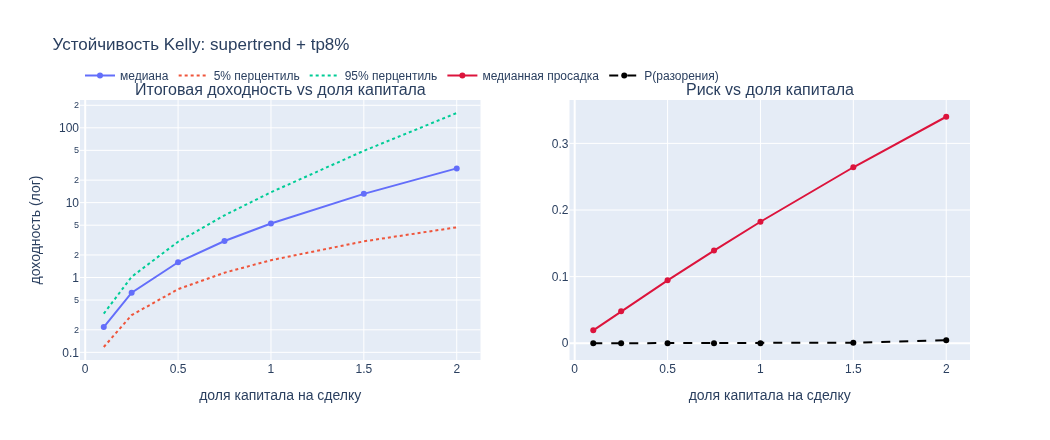

In [12]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Итоговая доходность vs доля капитала",
                                                    "Риск vs доля капитала"))
fig.add_trace(go.Scatter(x=robust.index, y=robust["final_ret_median"], name="медиана",
                         mode="lines+markers", line=dict(width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=robust.index, y=robust["final_ret_p5"], name="5% перцентиль",
                         mode="lines", line=dict(dash="dot")), row=1, col=1)
fig.add_trace(go.Scatter(x=robust.index, y=robust["final_ret_p95"], name="95% перцентиль",
                         mode="lines", line=dict(dash="dot")), row=1, col=1)
fig.add_trace(go.Scatter(x=robust.index, y=robust["maxdd_median"], name="медианная просадка",
                         mode="lines+markers", line=dict(color="crimson")), row=1, col=2)
fig.add_trace(go.Scatter(x=robust.index, y=robust["ruin_prob"], name="P(разорения)",
                         mode="lines+markers", line=dict(color="black", dash="dash")), row=1, col=2)
fig.update_xaxes(title_text="доля капитала на сделку")
fig.update_yaxes(type="log", title_text="доходность (лог)", row=1, col=1)
fig.update_layout(width=1050, height=440, title=f"Устойчивость Kelly: {MC_LABEL}",
                  legend=dict(orientation="h", y=1.15))
show(fig)

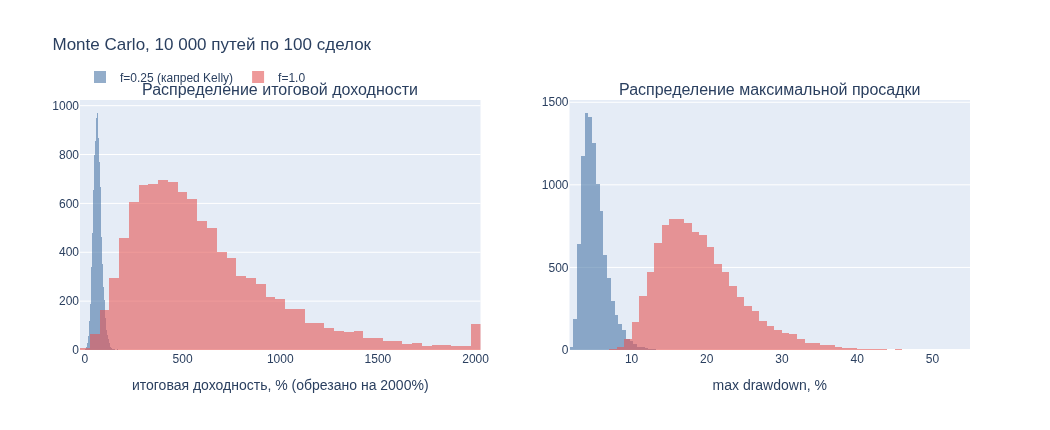

f=0.25: P(разорения)=0.0000, P(убытка)=0.0000, медианная просадка 4.8%
f=1.00: P(разорения)=0.0001, P(убытка)=0.0002, медианная просадка 18.2%


In [13]:
mc_quarter = simulate_trade_sequences(trade_returns[MC_LABEL], fraction=0.25, n_sims=10_000, n_trades=100)
mc_full = simulate_trade_sequences(trade_returns[MC_LABEL], fraction=1.0, n_sims=10_000, n_trades=100)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Распределение итоговой доходности", "Распределение максимальной просадки"))
for mc, color, label in ((mc_quarter, "#4C78A8", "f=0.25 (капped Kelly)"), (mc_full, "#E45756", "f=1.0")):
    fig.add_trace(go.Histogram(x=np.clip(mc.final_returns, -1, 20) * 100, nbinsx=60, name=label,
                               marker_color=color, opacity=0.6), row=1, col=1)
    fig.add_trace(go.Histogram(x=mc.max_drawdowns * 100, nbinsx=60, name=label, marker_color=color,
                               opacity=0.6, showlegend=False), row=1, col=2)
fig.update_xaxes(title_text="итоговая доходность, % (обрезано на 2000%)", row=1, col=1)
fig.update_xaxes(title_text="max drawdown, %", row=1, col=2)
fig.update_layout(barmode="overlay", width=1050, height=430,
                  title="Monte Carlo, 10 000 путей по 100 сделок", legend=dict(orientation="h", y=1.15))
show(fig)

print(f"f=0.25: P(разорения)={mc_quarter.ruin_prob:.4f}, P(убытка)={float((mc_quarter.final_returns<0).mean()):.4f}, "
      f"медианная просадка {np.median(mc_quarter.max_drawdowns):.1%}")
print(f"f=1.00: P(разорения)={mc_full.ruin_prob:.4f}, P(убытка)={float((mc_full.final_returns<0).mean()):.4f}, "
      f"медианная просадка {np.median(mc_full.max_drawdowns):.1%}")

## 7. Оценка риска переобучения (сводная)

Три независимых источника:

1. **Флаги этапа 02** — деградация Sharpe, ранговая нестабильность сетки,
   OOS-провал IS-победителя;
2. **Walk-forward efficiency** — переносимость при пере-оптимизации
   (≈1 — здорово, ≪1 — оверфит, ≤0 — сломано);
3. **Ширина bootstrap-интервала Kelly** — оценочный риск: слишком мало
   сделок, чтобы доверять точным цифрам.

In [14]:
overfit_view = strategy_summary.loc[TOP_STRATEGIES,
    ["overfit_flags", "sharpe_degradation", "is_oos_rank_corr"]].copy()
overfit_view["wf_efficiency"] = wf_table["wf_efficiency"]
overfit_view["wf_param_stability"] = wf_table["param_stability"]
overfit_view.round(3)

,overfit_flags,sharpe_degradation,is_oos_rank_corr,wf_efficiency,wf_param_stability
strategy,,,,,
ema_rsi,1,0.101,0.130,0.545,0.000
roc_momentum,0,-0.494,0.632,0.371,0.667
ichimoku,0,-0.749,0.325,0.728,0.000
supertrend,0,0.503,0.244,-0.198,0.333
triple_ema,0,0.298,0.403,NaN,NaN
vwap_volume,0,0.222,0.735,NaN,NaN


In [15]:
suspects_all = strategy_summary[strategy_summary["overfit_flags"] >= 2].index.tolist()
wf_broken = wf_table[wf_table["wf_efficiency"] < 0.3].index.tolist()
print("Стратегии с флагами переобучения на этапе 02 (>= 2):", ", ".join(suspects_all))
print("Стратегии, не прошедшие walk-forward (efficiency < 0.3):", ", ".join(wf_broken) or "нет")

Стратегии с флагами переобучения на этапе 02 (>= 2): macd_trend_filter, cci_reversion, zscore_reversion, rsi_reversion, psar, momentum
Стратегии, не прошедшие walk-forward (efficiency < 0.3): supertrend


## 8. Итоговые выводы и рекомендации

### ТОП стратегий (сквозной итог всех этапов)

1. **ema_rsi** (гибрид: EMA-тренд + RSI-pullback) — лидер robust-рейтинга,
   лучший walk-forward (efficiency ~0.5, OOS Sharpe ~0.85), выигрывает от
   частичной фиксации прибыли. Слабое место — нестабильность выбираемых
   параметров между окнами.
2. **roc_momentum** — простая (2 параметра), стабильная сетка, реальное
   улучшение от Take Profit; walk-forward умеренный.
3. **ichimoku / triple_ema / ema_adx** — устойчивые трендовые подходы
   второго эшелона; triple_ema дополнительно улучшается фильтрами
   `htf_up` и `not_stretched` (этап 04).
4. **supertrend** — предупреждающий кейс: сильный на фикс. сплите 70/30 и
   с TP-механикой, но walk-forward с пере-оптимизацией проваливается
   (efficiency < 0) — его параметры не переносятся между режимами.

### Лучшие методы управления позицией

* **Take Profit** и **частичная фиксация** — единственные механики с
  систематическим реальным улучшением (этап 03);
* **Time Stop / Break Even** — типичные ложные улучшения, не применять
  без веских причин;
* выход по противоположному сигналу — сильный baseline.

### Управление капиталом — рекомендации по применению

* Полному Kelly не доверять никогда: на десятках сделок он не идентифицирован
  (CI шире медианы в разы) и лежит далеко за разумным плечом.
* Практическое правило из Monte Carlo: **доля = min(quarter Kelly,
  25% капитала, 2% риска на сделку по хвостовому убытку)** — в этом прогоне
  ограничения дали 15–25% капитала: медианная просадка ~5%, P(разорения) ≈ 0,
  P(убытка за 100 сделок) ≈ 0.
* Пересчитывать Kelly-статистику регулярно и после каждых ~20 сделок.

### Признаки переобучения (чек-лист проекта)

* ранговая корреляция IS↔OOS сетки < 0.2 (этап 02);
* деградация Sharpe IS-победителя > 70%;
* walk-forward efficiency < 0.3 или отрицательная;
* новый «лучший» набор параметров в каждом окне (param_stability ≈ 0);
* механики/фильтры, улучшающие только IS (этапы 03–04);
* bootstrap-интервал Kelly шире самой оценки.

### Дальнейшее развитие

1. Реальные данные: мульти-инструментные прогоны (Yahoo / MOEX / Polygon —
   лоадеры добавляются одним классом), кросс-инструментная устойчивость.
2. Портфель стратегий: аллокация между некоррелированными лидерами
   (ema_rsi + roc_momentum) вместо одной стратегии.
3. Режимные переключатели: включать mean-reversion в `range_highvol`,
   тренд — в `trend_up` (карта режимов из этапа 04).
4. Исполнение: intraday-данные, задержки, частичные заполнения; учет
   заемного плеча в Monte Carlo.
5. Deflated Sharpe Ratio / White's Reality Check для формальной поправки
   на множественное тестирование.

### Инструкции по запуску

```bash
python3.12 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt && pip install -e . --no-deps
pytest                                   # 87 тестов инфраструктуры
python scripts/run_notebook.py notebooks/01_repository_setup.ipynb   # и далее 02..05
```

Порядок ноутбуков: 01 → 02 → 03 → 04 → 05; каждый самодостаточен
(пересчитывает нужные ему результаты), артефакты пишутся в `results/`.